<a href="https://colab.research.google.com/github/zFonta/CEIA_Trabajos_Grupales/blob/main/B2_AMq_AprendizajeDeMaquina/F1_TP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Final Aprendizaje de Máquina - 2B 2026
# Machine Learning - Formula 1

### Docentes:
 - Facundo Adrián Lucianna
 - Maria Carina Roldán
### Alumnos:
 -Juan Sebastián Bonal, jsbonals@gmail.com <br>
 -Federico Santiago Fontanari, federicofontanari@gmail.com <br>
 -Jose Andres Montes de Oca, amontesdeoca1982@gmail.com <br>


# Notebook de preprocesamiento de datos EDA

## Librerias y Setup

In [6]:
import kagglehub
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import requests
import time
import numpy as np
import missingno as msno

# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Descripción del Dataset

Dataset a nivel de vuelta para carreras de Fórmula 1, donde cada fila representa una vuelta completada por un piloto.

*Fuente:* [F1 Strategy Dataset | Pit Stop Prediction](https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction)

| Columna | Descripción |
|---|---|
| Year | Temporada/año de la carrera |
| Race | Nombre del Gran Premio |
| Driver | Código del piloto |
| LapNumber | Índice de la vuelta dentro de la carrera |
| Position | Posición del piloto en esa vuelta |
| LapTime (s) | Tiempo de vuelta en segundos |
| Stint | Número de stint (tanda) de neumáticos |
| TyreLife | Cantidad de vueltas con el neumático actual |
| Normalized_TyreLife | Vida del neumático normalizada dentro del stint |
| Compound_Encoded | Compuesto de neumático (codificado numéricamente) |
| LapTime_Delta | Cambio en el tiempo de vuelta respecto a la vuelta anterior |
| Cumulative_Degradation | Caída acumulada de rendimiento del neumático |
| Position_Change | Ganancia/pérdida de posición respecto a la vuelta anterior |
| RaceProgress | Fracción de la carrera completada (0 → 1) |
| PitStop | Si el piloto entró a boxes en esa vuelta (0/1) |
| PitNextLap | Variable target original: si el piloto entrará a boxes en la próxima vuelta (0/1) |

## 1 Ingesta de Datos

### 1.1 Diccionarios - Ground Truth

- Creamos un diccionario unificando el nombre de las carreras
- Tambien creamos un diccionario unificando el numero, nombre y apellido, nombre corto y escuderia
- Todo esto es necesario porque varios pilotos cambiaron de escuderia duante un mismo año, y en algunos casos hasta de numero

In [7]:
# ---------------------------------------------------------
# DICCIONARIOS Y DIMENSIONES (Reference Data)
# ---------------------------------------------------------

# 1. Mapeo de Carreras (API Location -> Kaggle Race)
map_carreras = {
    'Sakhir': 'Bahrain Grand Prix', 'Jeddah': 'Saudi Arabian Grand Prix',
    'Melbourne': 'Australian Grand Prix', 'Baku': 'Azerbaijan Grand Prix',
    'Miami': 'Miami Grand Prix', 'Miami Gardens': 'Miami Grand Prix',
    'Imola': 'Emilia Romagna Grand Prix', 'Monaco': 'Monaco Grand Prix',
    'Barcelona': 'Spanish Grand Prix', 'Montréal': 'Canadian Grand Prix',
    'Spielberg': 'Austrian Grand Prix', 'Silverstone': 'British Grand Prix',
    'Budapest': 'Hungarian Grand Prix', 'Spa-Francorchamps': 'Belgian Grand Prix',
    'Zandvoort': 'Dutch Grand Prix', 'Monza': 'Italian Grand Prix',
    'Marina Bay': 'Singapore Grand Prix', 'Suzuka': 'Japanese Grand Prix',
    'Lusail': 'Qatar Grand Prix', 'Austin': 'United States Grand Prix',
    'Mexico City': 'Mexico City Grand Prix', 'São Paulo': 'São Paulo Grand Prix',
    'Las Vegas': 'Las Vegas Grand Prix', 'Yas Island': 'Abu Dhabi Grand Prix',
    'Shanghai': 'Chinese Grand Prix'
}

# 2. Dimensión de Pilotos por Año, Equipo, Acrónimo y Posición Final
pilotos = [
    # 2023
    [2023, 1,  'Max Verstappen',        'VER', 'Red Bull', 1],
    [2023, 2,  'Logan Sargeant',        'SAR', 'Williams', 21],
    [2023, 3,  'Daniel Ricciardo',      'RIC', 'RB', 17],
    [2023, 4,  'Lando Norris',          'NOR', 'McLaren', 6],
    [2023, 10, 'Pierre Gasly',          'GAS', 'Alpine', 11],
    [2023, 11, 'Sergio Pérez',          'PER', 'Red Bull', 2],
    [2023, 14, 'Fernando Alonso',       'ALO', 'Aston Martin', 4],
    [2023, 16, 'Charles Leclerc',       'LEC', 'Ferrari', 5],
    [2023, 18, 'Lance Stroll',          'STR', 'Aston Martin', 10],
    [2023, 20, 'Kevin Magnussen',       'MAG', 'Haas', 19],
    [2023, 21, 'Nyck de Vries',         'DEV', 'RB', 22],
    [2023, 22, 'Yuki Tsunoda',          'TSU', 'RB', 14],
    [2023, 23, 'Alexander Albon',       'ALB', 'Williams', 13],
    [2023, 24, 'Zhou Guanyu',           'ZHO', 'Sauber', 18],
    [2023, 27, 'Nico Hülkenberg',       'HUL', 'Haas', 16],
    [2023, 31, 'Esteban Ocon',          'OCO', 'Alpine', 12],
    [2023, 40, 'Liam Lawson',           'LAW', 'RB', 20],
    [2023, 44, 'Lewis Hamilton',        'HAM', 'Mercedes', 3],
    [2023, 55, 'Carlos Sainz',          'SAI', 'Ferrari', 7],
    [2023, 63, 'George Russell',        'RUS', 'Mercedes', 8],
    [2023, 77, 'Valtteri Bottas',       'BOT', 'Sauber', 15],
    [2023, 81, 'Oscar Piastri',         'PIA', 'McLaren', 9],

    # 2024
    [2024, 1,  'Max Verstappen',        'VER', 'Red Bull', 1],
    [2024, 2,  'Logan Sargeant',        'SAR', 'Williams', 22],
    [2024, 3,  'Daniel Ricciardo',      'RIC', 'RB', 17],
    [2024, 4,  'Lando Norris',          'NOR', 'McLaren', 2],
    [2024, 10, 'Pierre Gasly',          'GAS', 'Alpine', 10],
    [2024, 11, 'Sergio Pérez',          'PER', 'Red Bull', 8],
    [2024, 14, 'Fernando Alonso',       'ALO', 'Aston Martin', 9],
    [2024, 16, 'Charles Leclerc',       'LEC', 'Ferrari', 3],
    [2024, 18, 'Lance Stroll',          'STR', 'Aston Martin', 13],
    [2024, 20, 'Kevin Magnussen',       'MAG', 'Haas', 15],
    [2024, 22, 'Yuki Tsunoda',          'TSU', 'RB', 12],
    [2024, 23, 'Alexander Albon',       'ALB', 'Williams', 16],
    [2024, 24, 'Zhou Guanyu',           'ZHO', 'Sauber', 21],
    [2024, 27, 'Nico Hülkenberg',       'HUL', 'Haas', 11],
    [2024, 30, 'Liam Lawson',           'LAW', 'RB', 20],
    [2024, 31, 'Esteban Ocon',          'OCO', 'Alpine', 14],
    [2024, 38, 'Oliver Bearman',        'BEA', 'Ferrari', 18],
    [2024, 43, 'Franco Colapinto',      'COL', 'Williams', 19],
    [2024, 44, 'Lewis Hamilton',        'HAM', 'Mercedes', 7],
    [2024, 50, 'Oliver Bearman',        'BEA', 'Haas', 18],
    [2024, 55, 'Carlos Sainz',          'SAI', 'Ferrari', 5],
    [2024, 61, 'Jack Doohan',           'DOO', 'Alpine', 24],
    [2024, 63, 'George Russell',        'RUS', 'Mercedes', 6],
    [2024, 77, 'Valtteri Bottas',       'BOT', 'Sauber', 23],
    [2024, 81, 'Oscar Piastri',         'PIA', 'McLaren', 4],

    # 2025 (Corregido, sin duplicados de Tsunoda y Lawson)
    [2025, 1,  'Max Verstappen',       'VER', 'Red Bull', 2],
    [2025, 4,  'Lando Norris',         'NOR', 'McLaren', 1],
    [2025, 5,  'Gabriel Bortoleto',    'BOR', 'Sauber', 19],
    [2025, 6,  'Isack Hadjar',         'HAD', 'RB', 12],
    [2025, 7,  'Jack Doohan',          'DOO', 'Alpine', 21],
    [2025, 10, 'Pierre Gasly',         'GAS', 'Alpine', 18],
    [2025, 12, 'Andrea Kimi Antonelli', 'ANT', 'Mercedes', 7],
    [2025, 14, 'Fernando Alonso',      'ALO', 'Aston Martin', 10],
    [2025, 16, 'Charles Leclerc',      'LEC', 'Ferrari', 5],
    [2025, 18, 'Lance Stroll',         'STR', 'Aston Martin', 16],
    [2025, 22, 'Yuki Tsunoda',         'TSU', 'RB', 17],
    [2025, 23, 'Alexander Albon',      'ALB', 'Williams', 8],
    [2025, 27, 'Nico Hülkenberg',      'HUL', 'Sauber', 11],
    [2025, 30, 'Liam Lawson',          'LAW', 'RB', 14],
    [2025, 31, 'Esteban Ocon',         'OCO', 'Haas', 15],
    [2025, 43, 'Franco Colapinto',     'COL', 'Alpine', 20],
    [2025, 44, 'Lewis Hamilton',       'HAM', 'Ferrari', 6],
    [2025, 55, 'Carlos Sainz',         'SAI', 'Williams', 9],
    [2025, 63, 'George Russell',       'RUS', 'Mercedes', 4],
    [2025, 81, 'Oscar Piastri',        'PIA', 'McLaren', 3],
    [2025, 87, 'Oliver Bearman',       'BEA', 'Haas', 13],
]
dim_pilotos = pd.DataFrame(
    pilotos,
    columns=['year', 'driver_number', 'full_name', 'Driver', 'team_name', 'final_position']
)

# 3. Generar map_pilotos dinámicamente desde dim_pilotos
# (necesario para usar .map() en las otras celdas)
map_pilotos = dict(zip(dim_pilotos['full_name'], dim_pilotos['Driver']))


### 1.2 Carga de Base #1 - Kaggle

- Cargamos la base principal de Kaggle con el historico de las carreras
- Generamos la variable Target: PitNextLap_fixed
- Hacemos un QA de la base #1 para confirmar que tanto las carreras como los pilotos matcheen con los dicccionarios de Ground Truth creados al inicio

In [8]:
# Cargamos los datos

# The dataset handle
dataset_handle = "aadigupta1601/f1-strategy-dataset-pit-stop-prediction"


file_path = "f1_strategy_dataset_v6.csv"

data = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  dataset_handle,
  file_path
)


# Fix de la variable target
# 1. Aseguramos que los datos estén ordenados cronológicamente
data = data.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber']).query("Year > 2022")

# 2. Creamos la variable buscando los incrementos de Stint
data['PitNextLap_fixed'] = (
    data.groupby(['Year', 'Race', 'Driver'])['Stint'].shift(-1) > data['Stint']
)

# 3. La última vuelta de cada piloto devolverá NaN con el shift(-1), así que lo rellenamos con False
data['PitNextLap_fixed'] = data['PitNextLap_fixed'].fillna(False)

#### 1.2.1 QA de la Base de Kaggle

In [9]:
# QA de la Base #1

# 1. Extraer combinaciones únicas de Kaggle (data)
# data usa 'Year' (mayúscula) y 'Driver' (acrónimo)
data_drivers = data[['Year', 'Driver']].drop_duplicates().rename(columns={'Year': 'year'})

# 2. Cruzar ambas tablas (Outer Join) para ver qué coincide y qué falta
# dim_pilotos ya tiene la columna 'Driver' gracias a la refactorización superior
validacion = pd.merge(
    data_drivers,
    dim_pilotos,
    on=['year', 'Driver'],
    how='outer',
    indicator=True
)

solo_en_data = validacion[validacion['_merge'] == 'left_only']
solo_en_dim = validacion[validacion['_merge'] == 'right_only']
comunes = validacion[validacion['_merge'] == 'both']

print("--- RESULTADOS DE LA VALIDACIÓN (DATA KAGGLE vs DIM_PILOTOS) ---")
print(f"✅ Combinaciones perfectas encontradas (Año + Piloto): {len(comunes)}")

if not solo_en_data.empty:
    print("\n❌ [ERROR] Pilotos en tu base de datos (Kaggle) que NO ESTÁN en dim_pilotos para ese año:")
    display(solo_en_data[['year', 'Driver']])
else:
    print("\n✅ [OK] Todos los pilotos de Kaggle tienen su correspondencia en dim_pilotos.")

if not solo_en_dim.empty:
    print("\n⚠️ [ATENCIÓN] Pilotos en dim_pilotos que NO ESTÁN en tu base de datos de Kaggle para ese año:")
    print("(Esto puede ser normal si no llegaron a correr ni dar una sola vuelta)")
    display(solo_en_dim[['year', 'Driver', 'full_name', 'team_name']])


--- RESULTADOS DE LA VALIDACIÓN (DATA KAGGLE vs DIM_PILOTOS) ---
✅ Combinaciones perfectas encontradas (Año + Piloto): 68

✅ [OK] Todos los pilotos de Kaggle tienen su correspondencia en dim_pilotos.


### 1.3 Carga de Base #2 - OpenF1 API



- Descargamos la data del clima desde la API
- Tambien descargamos los datos de cada carrera desde la misma API
- Realizamos un QA de la informacion

#### 1.3.1 Datos Clima

In [10]:
BASE_URL = "https://api.openf1.org/v1"

def get_json(endpoint, params):
    r = requests.get(f"{BASE_URL}/{endpoint}", params=params)
    r.raise_for_status()
    return r.json()

# Paso 1: Obtener todas las sesiones de tipo "Race" para cada año
all_sessions = []
for year in [2023, 2024, 2025]:
    sessions = get_json("sessions", {"session_name": "Race", "year": year})
    all_sessions.extend(sessions)
    print(f"{year}: {len(sessions)} carreras encontradas")

sessions_df = pd.DataFrame(all_sessions)

# Paso 1.5: Obtener clima de cada sesión con sistema anti-bloqueo (Rate Limit) y Logs
print("\n☁️ Obteniendo datos oficiales del clima para las sesiones...")
weather_data = []

for index, row in sessions_df.iterrows():
    sk = row['session_key']
    year = row['year']
    location = row['location']

    max_retries = 3
    retry_delay = 5
    success = False

    for attempt in range(max_retries):
        try:
            w_json = get_json("weather", {"session_key": sk})
            if w_json:
                df_w = pd.DataFrame(w_json)
                session_weather = {
                    'session_key': sk,
                    'Air_Temp_Mean': df_w['air_temperature'].mean(),
                    'Track_Temp_Mean': df_w['track_temperature'].mean(),
                    'Wind_Speed_Mean': df_w['wind_speed'].mean(),
                    'Humidity_Mean': df_w['humidity'].mean(),
                    'Rainfall_Max': df_w['rainfall'].max()
                }
                weather_data.append(session_weather)
                success = True
            else:
                print(f"   [AVISO] La API no devolvió datos de clima para: {year} - {location} (session_key={sk})")
                success = True # La petición fue exitosa, simplemente no hay datos en la fuente
            break # Éxito (con o sin datos), salir del loop de reintentos

        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 429:
                print(f"   ⚠️ Rate limit en clima ({year}-{location}). Reintentando en {retry_delay}s...")
                time.sleep(retry_delay)
                retry_delay *= 2
            else:
                print(f"   ❌ Error HTTP {e.response.status_code} en clima para: {year} - {location}")
                break
        except Exception as e:
            print(f"   ❌ Error inesperado en clima para {year} - {location}: {e}")
            break

    if not success and attempt == max_retries - 1:
        print(f"   ❌ Se agotaron los reintentos para: {year} - {location}")

    time.sleep(0.5)

df_weather = pd.DataFrame(weather_data)
print(f"✅ Clima descargado exitosamente para {len(df_weather)} sesiones.")

2023: 23 carreras encontradas
2024: 24 carreras encontradas
2025: 24 carreras encontradas

☁️ Obteniendo datos oficiales del clima para las sesiones...
   ❌ Error HTTP 404 en clima para: 2023 - Imola
   ⚠️ Rate limit en clima (2025-Spielberg). Reintentando en 5s...
   ⚠️ Rate limit en clima (2025-Spielberg). Reintentando en 10s...
   ⚠️ Rate limit en clima (2025-Spielberg). Reintentando en 20s...
   ❌ Se agotaron los reintentos para: 2025 - Spielberg
✅ Clima descargado exitosamente para 69 sesiones.


#### 1.3.2 Datos Laps

In [11]:
all_laps = []

for _, row in sessions_df.iterrows():
    session_key = row["session_key"]
    location = row["location"]
    year = row["year"]

    print(f"Descargando laps: {year} - {location} (session_key={session_key})")

    laps = [] # Initialize laps to an empty list
    max_retries = 3
    retry_delay = 5

    for attempt in range(max_retries):
        try:
            laps = get_json("laps", {"session_key": session_key})
            break # Exit retry loop on success
        except requests.exceptions.HTTPError as e:
            # Handle 404 errors specifically, which often means no data exists for that session
            if e.response.status_code == 404:
                print(f"Advertencia: No se encontraron laps para {year} - {location} (session_key={session_key}). Saltando esta sesión.")
                break
            # Handle 429 Rate Limit error by waiting and retrying
            elif e.response.status_code == 429:
                print(f"⚠️ Error 429 (Demasiadas peticiones). Esperando {retry_delay} segundos antes de reintentar... (Intento {attempt + 1}/{max_retries})")
                time.sleep(retry_delay)
                retry_delay *= 2 # Exponential backoff
            else:
                # Re-raise other HTTP errors to ensure other issues are caught
                raise

    if laps:
        df_laps = pd.DataFrame(laps)
        df_laps["year"] = year
        df_laps["location"] = location
        all_laps.append(df_laps)

    time.sleep(3)  # Incrementar un poco el delay base para evitar futuros rate limits

# Consolidar todo usando un nuevo nombre de variable para no sobrescribir el dataset de Kaggle
if all_laps:
    data_api = pd.concat(all_laps, ignore_index=True)
    print(f"Total de laps descargados: {len(data_api)}")
else:
    print("No se descargaron datos de vueltas.")

# Ordenamos y renombramos el DataFrame
df_laps = data_api.sort_values(by=['year', 'location', 'driver_number', 'lap_number']).reset_index(drop=True).copy()


Descargando laps: 2023 - Sakhir (session_key=7953)
Descargando laps: 2023 - Jeddah (session_key=7779)
Descargando laps: 2023 - Melbourne (session_key=7787)
Descargando laps: 2023 - Baku (session_key=9070)
Descargando laps: 2023 - Miami (session_key=9078)
Descargando laps: 2023 - Imola (session_key=9086)
Advertencia: No se encontraron laps para 2023 - Imola (session_key=9086). Saltando esta sesión.
Descargando laps: 2023 - Monaco (session_key=9094)
Descargando laps: 2023 - Barcelona (session_key=9102)
Descargando laps: 2023 - Montréal (session_key=9110)
Descargando laps: 2023 - Spielberg (session_key=9118)
Descargando laps: 2023 - Silverstone (session_key=9126)
Descargando laps: 2023 - Budapest (session_key=9133)
Descargando laps: 2023 - Spa-Francorchamps (session_key=9141)
Descargando laps: 2023 - Zandvoort (session_key=9149)
Descargando laps: 2023 - Monza (session_key=9157)
Descargando laps: 2023 - Marina Bay (session_key=9165)
Descargando laps: 2023 - Suzuka (session_key=9173)
Descar

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\2786698391.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_api = pd.concat(all_laps, ignore_index=True)


Total de laps descargados: 77373


##### 1.3.2.1 QA de Laps

In [12]:
# QA de la base de carreras

# Extraer combinaciones únicas de año, número de piloto y locación de la API (data2)
api_drivers = df_laps[['year', 'driver_number', 'location']].drop_duplicates()

# Cruzar con dim_pilotos (usando year y driver_number)
check_df = pd.merge(
    api_drivers,
    dim_pilotos[['year', 'driver_number', 'full_name', 'team_name']].drop_duplicates(),
    on=['year', 'driver_number'],
    how='left',
    indicator=True
)

# Filtrar los que están en la API pero no en dim_pilotos
missing_in_dim = check_df[check_df['_merge'] == 'left_only']

print("--- VALIDACIÓN DE PILOTOS EN API vs DIM_PILOTOS ---")
if missing_in_dim.empty:
    print("✅ [OK] Todos los pilotos (por año y número) de la API existen en tu tabla dim_pilotos.")
else:
    print("❌ [ERROR] Los siguientes pilotos aparecen en la API pero NO están en dim_pilotos para ese año:")
    display(missing_in_dim[['year', 'location', 'driver_number']])


--- VALIDACIÓN DE PILOTOS EN API vs DIM_PILOTOS ---
✅ [OK] Todos los pilotos (por año y número) de la API existen en tu tabla dim_pilotos.


#### 1.3.3 Merge de Clima y Laps


- Vamos a mergear las bases anteriores

In [13]:
# 1. Crear DataFrame DIM_CARRERAS a partir de sessions_df (Dinámico)
dim_carreras = sessions_df[['meeting_key', 'session_key', 'location']].copy()
dim_carreras.rename(columns={'location': 'grand_prix'}, inplace=True)

# 2. Realizar los joins consecutivos
# Limpiamos columnas previas en data2 si existen para evitar duplicados (_x, _y)
columnas_a_limpiar = ['full_name', 'team_name', 'grand_prix']
data2_clean = df_laps.drop(columns=[col for col in columnas_a_limpiar if col in df_laps.columns])

# Unir pilotos (AHORA USANDO 'year' Y 'driver_number' COMO CLAVES)
data_intermedia = pd.merge(data2_clean, dim_pilotos, on=['year', 'driver_number'], how='left')

# Unir carreras usando la clave compuesta (meeting_key y session_key)
data_final = pd.merge(data_intermedia, dim_carreras, on=['meeting_key', 'session_key'], how='left')

# Unir variables del Clima
if 'df_weather' in globals():
    data_final = pd.merge(data_final, df_weather, on='session_key', how='left')

# 3. Mantener la consistencia de los años requeridos
data_final = data_final[data_final['year'].isin([2023, 2024, 2025])]


##### 1.4.1 QA Clima + Laps

In [14]:
print("--- ANÁLISIS DE CALIDAD DEL JOIN ---")

# 1. Chequeo de valores nulos en las columnas agregadas por los joins
print("\n1. Valores nulos por columna (foco en las agregadas):")
columnas_join = ['driver_number', 'full_name', 'team_name', 'meeting_key', 'session_key', 'grand_prix']

# Safely filter to only columns that actually exist in data_final
available_cols = [col for col in columnas_join if col in data_final.columns]
missing_cols = [col for col in columnas_join if col not in data_final.columns]

if missing_cols:
    print(f"[ADVERTENCIA] Las siguientes columnas no existen en data_final: {missing_cols}. ¿Ejecutaste la celda anterior?")

print(data_final[available_cols].isnull().sum())

# Verificar pilotos huérfanos (presentes en data2 pero no en dim_pilotos)
if 'full_name' in data_final.columns:
    pilotos_nulos = data_final[data_final['full_name'].isnull()]['driver_number'].unique()
    if len(pilotos_nulos) > 0:
        print(f"\n[ADVERTENCIA] Hay 'driver_number' sin datos en dim_pilotos: {pilotos_nulos}")
    else:
        print("\n[OK] Todos los 'driver_number' cruzaron correctamente con dim_pilotos.")

# Verificar sesiones huérfanas (presentes en data2 pero no en dim_carreras)
if 'grand_prix' in data_final.columns:
    carreras_nulas = data_final[data_final['grand_prix'].isnull()][['meeting_key', 'session_key', 'year']].drop_duplicates()
    if not carreras_nulas.empty:
        print(f"\n[ADVERTENCIA] Hay sesiones sin 'grand_prix' (faltan en dim_carreras):\n{carreras_nulas}")
    else:
        print("\n[OK] Todas las sesiones cruzaron correctamente con dim_carreras.")

# 2. Consistencia de driver_number a través de las carreras
if all(col in data_final.columns for col in ['driver_number', 'full_name', 'team_name', 'session_key']):
    print("\n2. Participación de pilotos (carreras únicas por driver_number):")
    consistencia_pilotos = data_final.groupby(['driver_number', 'full_name', 'team_name'])['session_key'].nunique().reset_index()
    consistencia_pilotos.rename(columns={'session_key': 'cantidad_carreras_corridas'}, inplace=True)
    display(consistencia_pilotos.sort_values(by='cantidad_carreras_corridas', ascending=False))

--- ANÁLISIS DE CALIDAD DEL JOIN ---

1. Valores nulos por columna (foco en las agregadas):
driver_number    0
full_name        0
team_name        0
meeting_key      0
session_key      0
grand_prix       0
dtype: int64

[OK] Todos los 'driver_number' cruzaron correctamente con dim_pilotos.

[OK] Todas las sesiones cruzaron correctamente con dim_carreras.

2. Participación de pilotos (carreras únicas por driver_number):


,driver_number,full_name,team_name,cantidad_carreras_corridas
0,1,Max Verstappen,Red Bull,70
3,4,Lando Norris,McLaren,70
11,16,Charles Leclerc,Ferrari,70
10,14,Fernando Alonso,Aston Martin,70
7,10,Pierre Gasly,Alpine,70
35,81,Oscar Piastri,McLaren,70
33,63,George Russell,Mercedes,70
15,22,Yuki Tsunoda,RB,70
16,23,Alexander Albon,Williams,69
12,18,Lance Stroll,Aston Martin,68


### 1.4 Merge Maestro (Base #1 Kaggle + Base #2 API)

- Vamos a juntar por un lado la base descargada de Kaggle con la base obtenida desde la API
- Se realizan los controles de QA necesarios

In [15]:
# 1. Preparar la data de la API (data_final) para el cruce
data_final_to_join = data_final.copy()

# Aplicar mapeos usando los diccionarios globales
data_final_to_join['Race'] = data_final_to_join['location'].map(map_carreras)
data_final_to_join['Driver'] = data_final_to_join['full_name'].map(map_pilotos)

# Estandarizar nombres de columnas para que coincidan con Kaggle (Case Sensitive)
data_final_to_join.rename(columns={'year': 'Year', 'lap_number': 'LapNumber'}, inplace=True)

# 2. Hacer el JOIN FINAL (RIGHT JOIN)
# Usamos RIGHT JOIN para que la API sea la base mandatoria.
# Si Kaggle no tiene una vuelta (como pasa en 2024/2025), se mantendrá la vuelta de la API con nulos en las columnas de Kaggle.
f1_master = pd.merge(
    data,
    data_final_to_join,
    on=['Year', 'Race', 'Driver', 'LapNumber'],
    how='right'
)

print(f"Total de registros en Kaggle (data, años 2023-2025): {len(data)}")
print(f"Total de registros en API (data_final): {len(data_final)}")
print(f"\n✅ ¡Cruce Exitoso! Total de registros en base unificada conservando todo el historial de la API: {len(f1_master)}")

# display(f1_master.head())

Total de registros en Kaggle (data, años 2023-2025): 79511
Total de registros en API (data_final): 77373

✅ ¡Cruce Exitoso! Total de registros en base unificada conservando todo el historial de la API: 77373


#### 1.4.1 QA Maestro

In [16]:
# Análisis de las vueltas que no cruzaron (Mismatches)
outer_join = pd.merge(
    data,
    data_final_to_join,
    on=['Year', 'Race', 'Driver', 'LapNumber'],
    how='outer',
    indicator=True
)

solo_kaggle = outer_join[outer_join['_merge'] == 'left_only']
solo_api = outer_join[outer_join['_merge'] == 'right_only']

print("--- DETALLE DE DIFERENCIAS ---")
print(f"Vueltas SOLO en Kaggle (No están o tienen distinto LapNumber en API): {len(solo_kaggle)}")
print(f"Vueltas SOLO en API (No están o tienen distinto LapNumber en Kaggle): {len(solo_api)}")

print("\n1. Muestra de vueltas que están en Kaggle pero no cruzaron con la API:")
display(solo_kaggle[['Year', 'Race', 'Driver', 'LapNumber', 'Position']].head(10))

print("\n2. Muestra de vueltas que están en la API pero no cruzaron con Kaggle:")
display(solo_api[['Year', 'Race', 'Driver', 'LapNumber', 'location']].head(10))

--- DETALLE DE DIFERENCIAS ---
Vueltas SOLO en Kaggle (No están o tienen distinto LapNumber en API): 3390
Vueltas SOLO en API (No están o tienen distinto LapNumber en Kaggle): 1252

1. Muestra de vueltas que están en Kaggle pero no cruzaron con la API:


,Year,Race,Driver,LapNumber,Position
17993,2023,Pre-Season Testing,ALB,1,10.0
17994,2023,Pre-Season Testing,ALB,2,10.0
17995,2023,Pre-Season Testing,ALB,3,10.0
17996,2023,Pre-Season Testing,ALB,4,10.0
17997,2023,Pre-Season Testing,ALB,5,10.0
17998,2023,Pre-Season Testing,ALB,6,10.0
17999,2023,Pre-Season Testing,ALB,7,10.0
18000,2023,Pre-Season Testing,ALB,8,10.0
18001,2023,Pre-Season Testing,ALB,9,10.0
18002,2023,Pre-Season Testing,ALB,10,10.0



2. Muestra de vueltas que están en la API pero no cruzaron con Kaggle:


,Year,Race,Driver,LapNumber,location
867,2023,Abu Dhabi Grand Prix,SAI,58,Yas Island
1100,2023,Abu Dhabi Grand Prix,VER,59,Yas Island
1165,2023,Australian Grand Prix,ALB,7,Melbourne
1173,2023,Australian Grand Prix,ALO,8,Melbourne
1174,2023,Australian Grand Prix,ALO,9,Melbourne
1220,2023,Australian Grand Prix,ALO,55,Melbourne
1221,2023,Australian Grand Prix,ALO,56,Melbourne
1222,2023,Australian Grand Prix,ALO,57,Melbourne
1223,2023,Australian Grand Prix,ALO,58,Melbourne
1224,2023,Australian Grand Prix,ALO,59,Melbourne


* Vemos que hay carreras que no deberian estar (pre-season testing)
* Tambien descurbimos carreras accidentadas en las ultimas dos vueltas, en donde los sensores no registraron lo mismo en ambas bases (Australia/Abu Dhabi 2023)
* No matchea la variable target en ambas bases, debido a las diferencias cuasadas en los registros de la entrada a pits causada por los accidentes

### 1.5 Limpieza de Casos Atípicos y Fix del Target

In [17]:
# Usaremos los datos oficiales de la API (data_final) como 'Ground Truth' externa
# La API provee 'is_pit_out_lap'. Si la vuelta N+1 es de salida, la N fue de entrada a pits.

df_api_check = data_final.sort_values(by=['session_key', 'driver_number', 'lap_number']).copy()

# 1. Definir la verdad absoluta según la API
df_api_check['API_PitNextLap'] = df_api_check.groupby(['session_key', 'driver_number'])['is_pit_out_lap'].shift(-1).fillna(False)

# 2. Preparar las columnas para el cruce con nuestro dataset
df_api_check['Race'] = df_api_check['grand_prix'].map(map_carreras)
df_api_check['Driver'] = df_api_check['full_name'].map(map_pilotos)
df_api_check.rename(columns={'year': 'Year', 'lap_number': 'LapNumber'}, inplace=True)

# 3. Cruzar la verdad de la API hacia f1_master
f1_master = pd.merge(
    f1_master,
    df_api_check[['Year', 'Race', 'Driver', 'LapNumber', 'API_PitNextLap']],
    on=['Year', 'Race', 'Driver', 'LapNumber'],
    how='left'
)

# 4. En lugar de ELIMINAR las vueltas ruidosas, simplemente confiamos en la API
# para la etiqueta de PitNextLap y CONSERVAMOS todas las filas.
f1_master['PitNextLap'] = f1_master['API_PitNextLap']
f1_master.drop(columns=['API_PitNextLap'], inplace=True)

print("--- VERIFICACIÓN CON API OPENF1 (Ground Truth Web) ---")
print("✅ Se ha actualizado la variable predictora 'PitNextLap' utilizando los datos oficiales de la API.")
print(f"✅ NO se eliminó ninguna vuelta. Total de registros intactos en f1_master: {len(f1_master)}")
print("\n(La exportación se realizará al final de la notebook, tras todos los controles de QA)")


C:\Users\Administrator\AppData\Local\Temp\ipykernel_21892\1991923803.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_api_check['API_PitNextLap'] = df_api_check.groupby(['session_key', 'driver_number'])['is_pit_out_lap'].shift(-1).fillna(False)


--- VERIFICACIÓN CON API OPENF1 (Ground Truth Web) ---
✅ Se ha actualizado la variable predictora 'PitNextLap' utilizando los datos oficiales de la API.
✅ NO se eliminó ninguna vuelta. Total de registros intactos en f1_master: 77373

(La exportación se realizará al final de la notebook, tras todos los controles de QA)


* Decidimos eliminar la ultima vuelta de cada carrera, ya que no tiene relevancia para predecir el target, ya que no hay vuelta siguiente a esa

In [18]:
print(f"Total de registros INICIALES: {len(f1_master)}")

# 1. Excluir carreras anómalas
carreras_excluidas = [
    (2023, 'Australian Grand Prix'),
    (2023, 'Azerbaijan Grand Prix'),
    (2025, 'Canadian Grand Prix')
]

mascara_outlier = pd.Series(False, index=f1_master.index)
for year, race in carreras_excluidas:
    mascara_outlier |= ((f1_master['Year'] == year) & (f1_master['Race'] == race))

# También excluir 'Pre-Season Testing'
mascara_outlier |= (f1_master['Race'] == 'Pre-Season Testing')

f1_master = f1_master[~mascara_outlier].copy()
print(f"Total de registros DESPUÉS de excluir carreras anómalas y Pre-Season Testing: {len(f1_master)}")

# 2. Eliminar la última vuelta de cada piloto (ruido para el modelo ML)
max_laps = f1_master.groupby(['Year', 'Race', 'Driver'])['LapNumber'].transform('max')
f1_master = f1_master[f1_master['LapNumber'] != max_laps].copy()
print(f"Total de registros DESPUÉS de eliminar la última vuelta de cada piloto: {len(f1_master)}")

# 3. Eliminar TODAS las variables que no se van a usar (redundantes y no deseadas para ML)
columnas_redundantes = ['location', 'grand_prix', 'full_name', 'driver_number']
to_delete = [
    "Stint", "Cumulative_Degradation", "PitStop", "PitNextLap", "RaceProgress",
    "Normalized_TyreLife", "meeting_key", "session_key", "is_pit_out_lap",
    "LapTime (s)", "segments_sector_1", "segments_sector_2", "segments_sector_3"
]
columnas_a_eliminar = columnas_redundantes + to_delete

f1_master = f1_master.drop(columns=columnas_a_eliminar, errors='ignore')
print(f"\n🧹 Columnas eliminadas exitosamente: {columnas_a_eliminar}")


Total de registros INICIALES: 77373
Total de registros DESPUÉS de excluir carreras anómalas y Pre-Season Testing: 74055
Total de registros DESPUÉS de eliminar la última vuelta de cada piloto: 72721

🧹 Columnas eliminadas exitosamente: ['location', 'grand_prix', 'full_name', 'driver_number', 'Stint', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'meeting_key', 'session_key', 'is_pit_out_lap', 'LapTime (s)', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3']


### 1.6 Conteos

#### 1.6.1 Carreras por Año

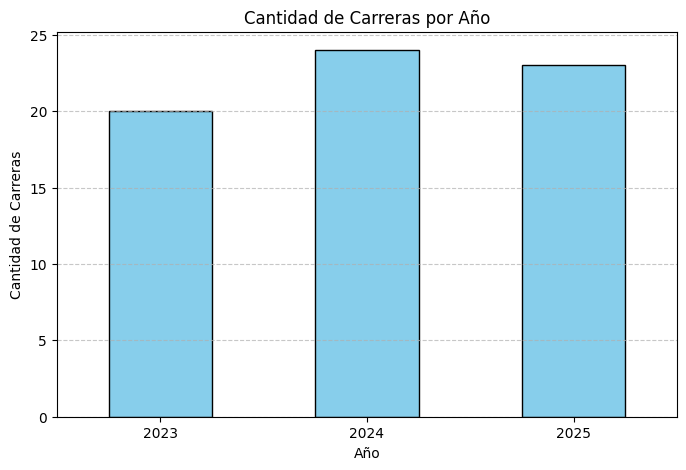

In [19]:
# Preparar la variable 'data' para las celdas de conteos/visualizaciones
data = f1_master.copy()
if 'date_start' in data.columns:
    data['periodo'] = pd.to_datetime(data['date_start'], format='mixed').dt.date

# Agrupar por año y contar la cantidad de carreras únicas
carreras_por_ano = data.groupby('Year')['Race'].nunique()

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))
carreras_por_ano.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Cantidad de Carreras por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Carreras')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

* Luego de la depuracion, se osberva que hay entre 20 y 24 carreras por año calendario

#### 1.6.2 Carreras por Piloto

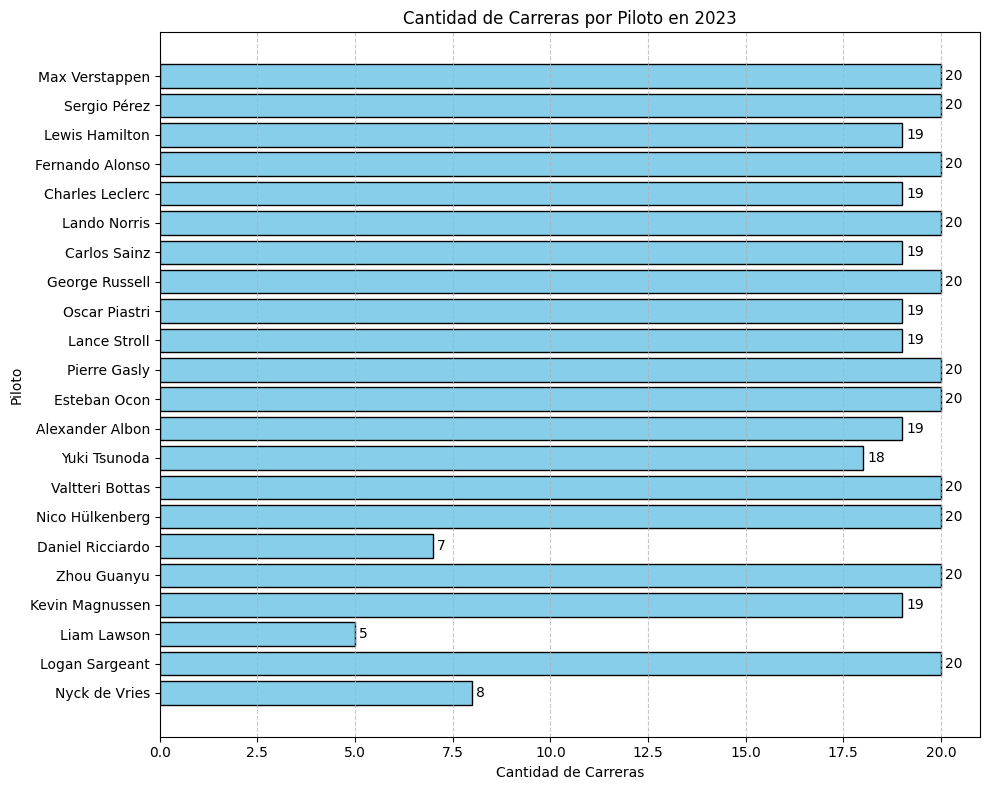

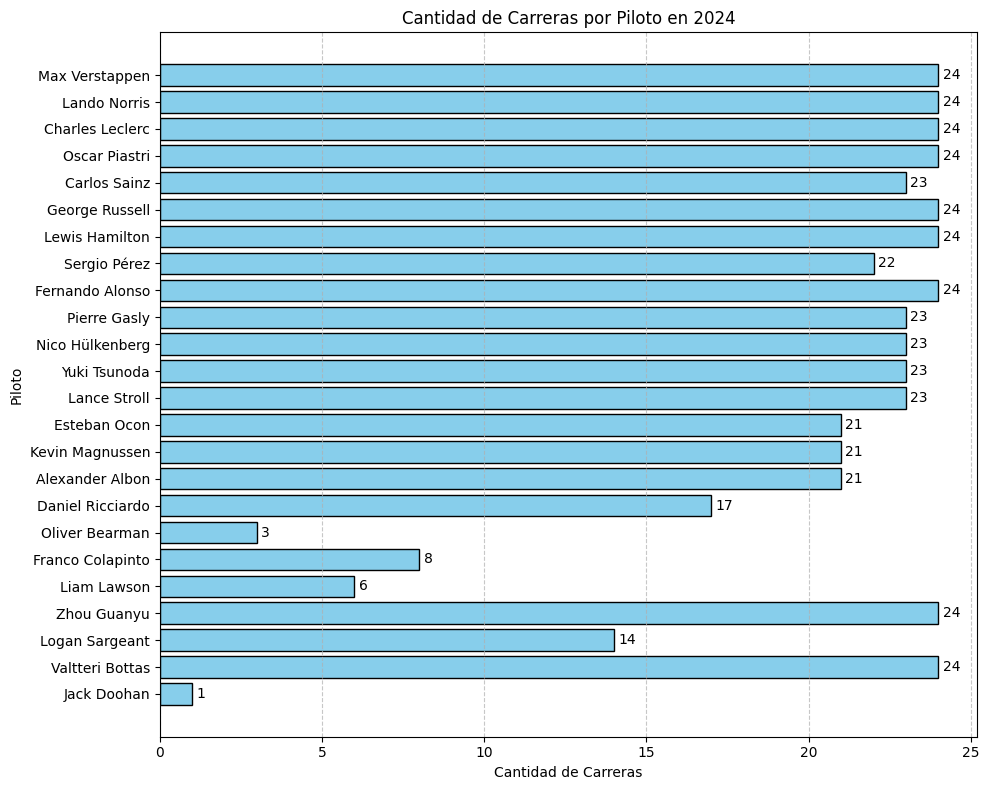

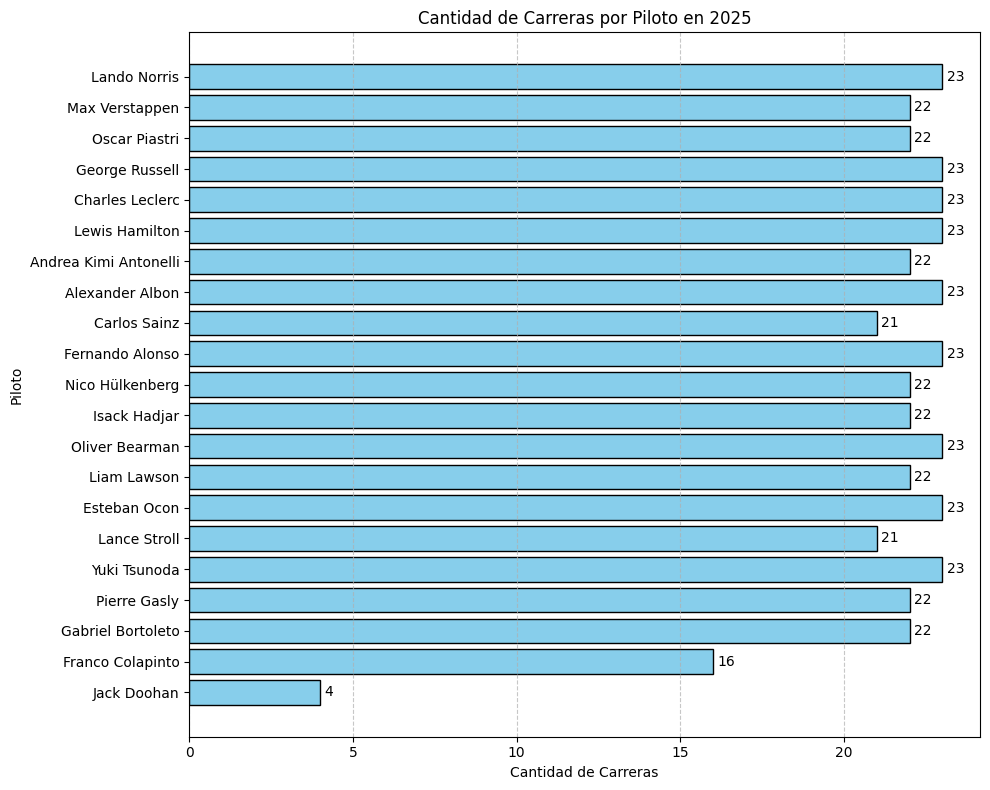

In [20]:
# Obtener los años únicos ordenados
anos = sorted(data['Year'].unique())

for ano in anos:
    # Filtrar datos por año
    data_ano = data[data['Year'] == ano]

    # Contar la cantidad de carreras únicas por piloto usando 'Driver' (ya que full_name fue eliminada)
    carreras_piloto = data_ano.groupby('Driver')['Race'].nunique().reset_index()

    # Traer la posición final y el full_name del diccionario dim_pilotos
    dim_pilotos_ano = dim_pilotos[dim_pilotos['year'] == ano][['Driver', 'full_name', 'final_position']]

    # Eliminar posibles duplicados (ej. los registros antiguos de 2025 con None)
    # priorizando aquellos que sí tienen una posición final numérica
    dim_pilotos_ano = dim_pilotos_ano.sort_values(by='final_position', na_position='last').drop_duplicates(subset=['Driver'])

    # Cruzar por 'Driver' en lugar de 'full_name'
    carreras_piloto = pd.merge(carreras_piloto, dim_pilotos_ano, on='Driver', how='left')

    # Los que no tienen posición final les asignamos 99 para que queden abajo
    carreras_piloto['final_position'] = carreras_piloto['final_position'].fillna(99)

    # Ordenar descendente por posición final (así el 1 queda último en el df y arriba en barh)
    carreras_piloto = carreras_piloto.sort_values(by=['final_position', 'Race'], ascending=[False, True])

    # Si por algún motivo no cruzó el full_name, usamos el Driver como respaldo
    carreras_piloto['nombre_mostrar'] = carreras_piloto['full_name'].fillna(carreras_piloto['Driver'])

    # Crear el gráfico
    plt.figure(figsize=(10, 8))
    bars = plt.barh(carreras_piloto['nombre_mostrar'], carreras_piloto['Race'], color='skyblue', edgecolor='black')

    # Agregar las etiquetas al final de cada barra
    plt.bar_label(bars, padding=3)

    plt.title(f'Cantidad de Carreras por Piloto en {ano}')
    plt.xlabel('Cantidad de Carreras')
    plt.ylabel('Piloto')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

* Aqui vemos que algunos pilotos fueron reemplazados por otros en las distintas temporadas

#### 1.6.3 Vueltas por Piloto

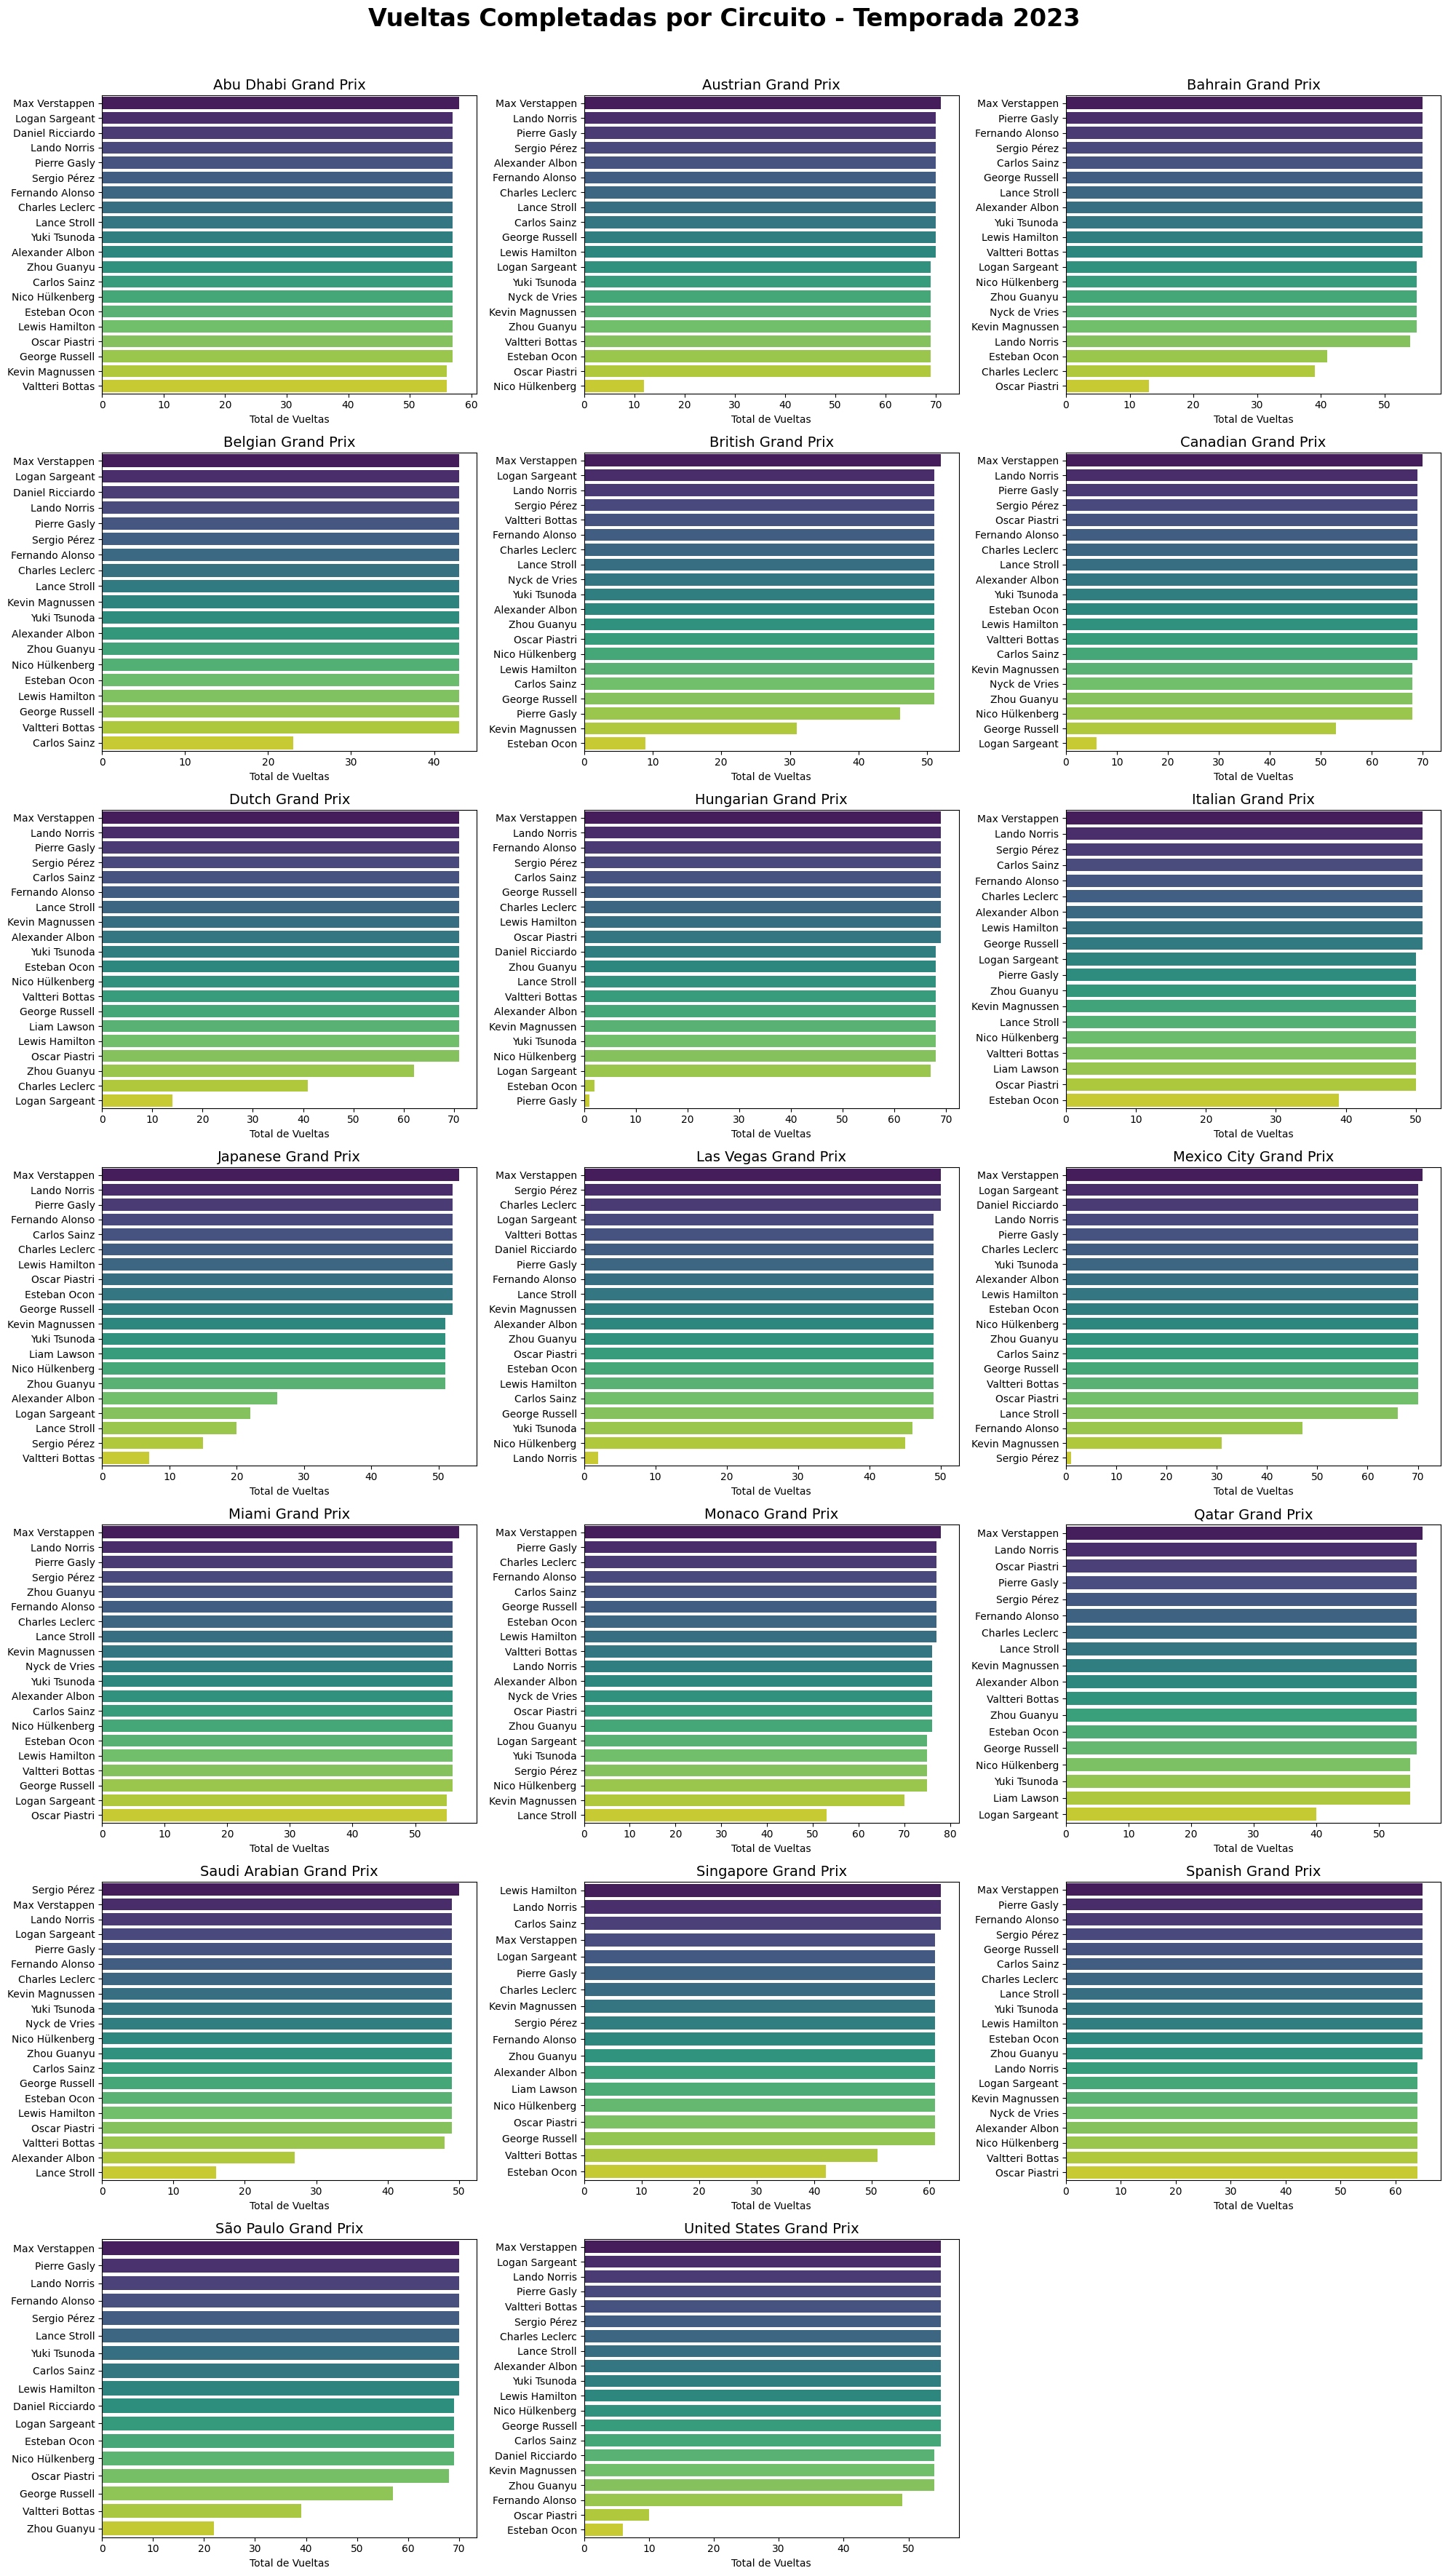

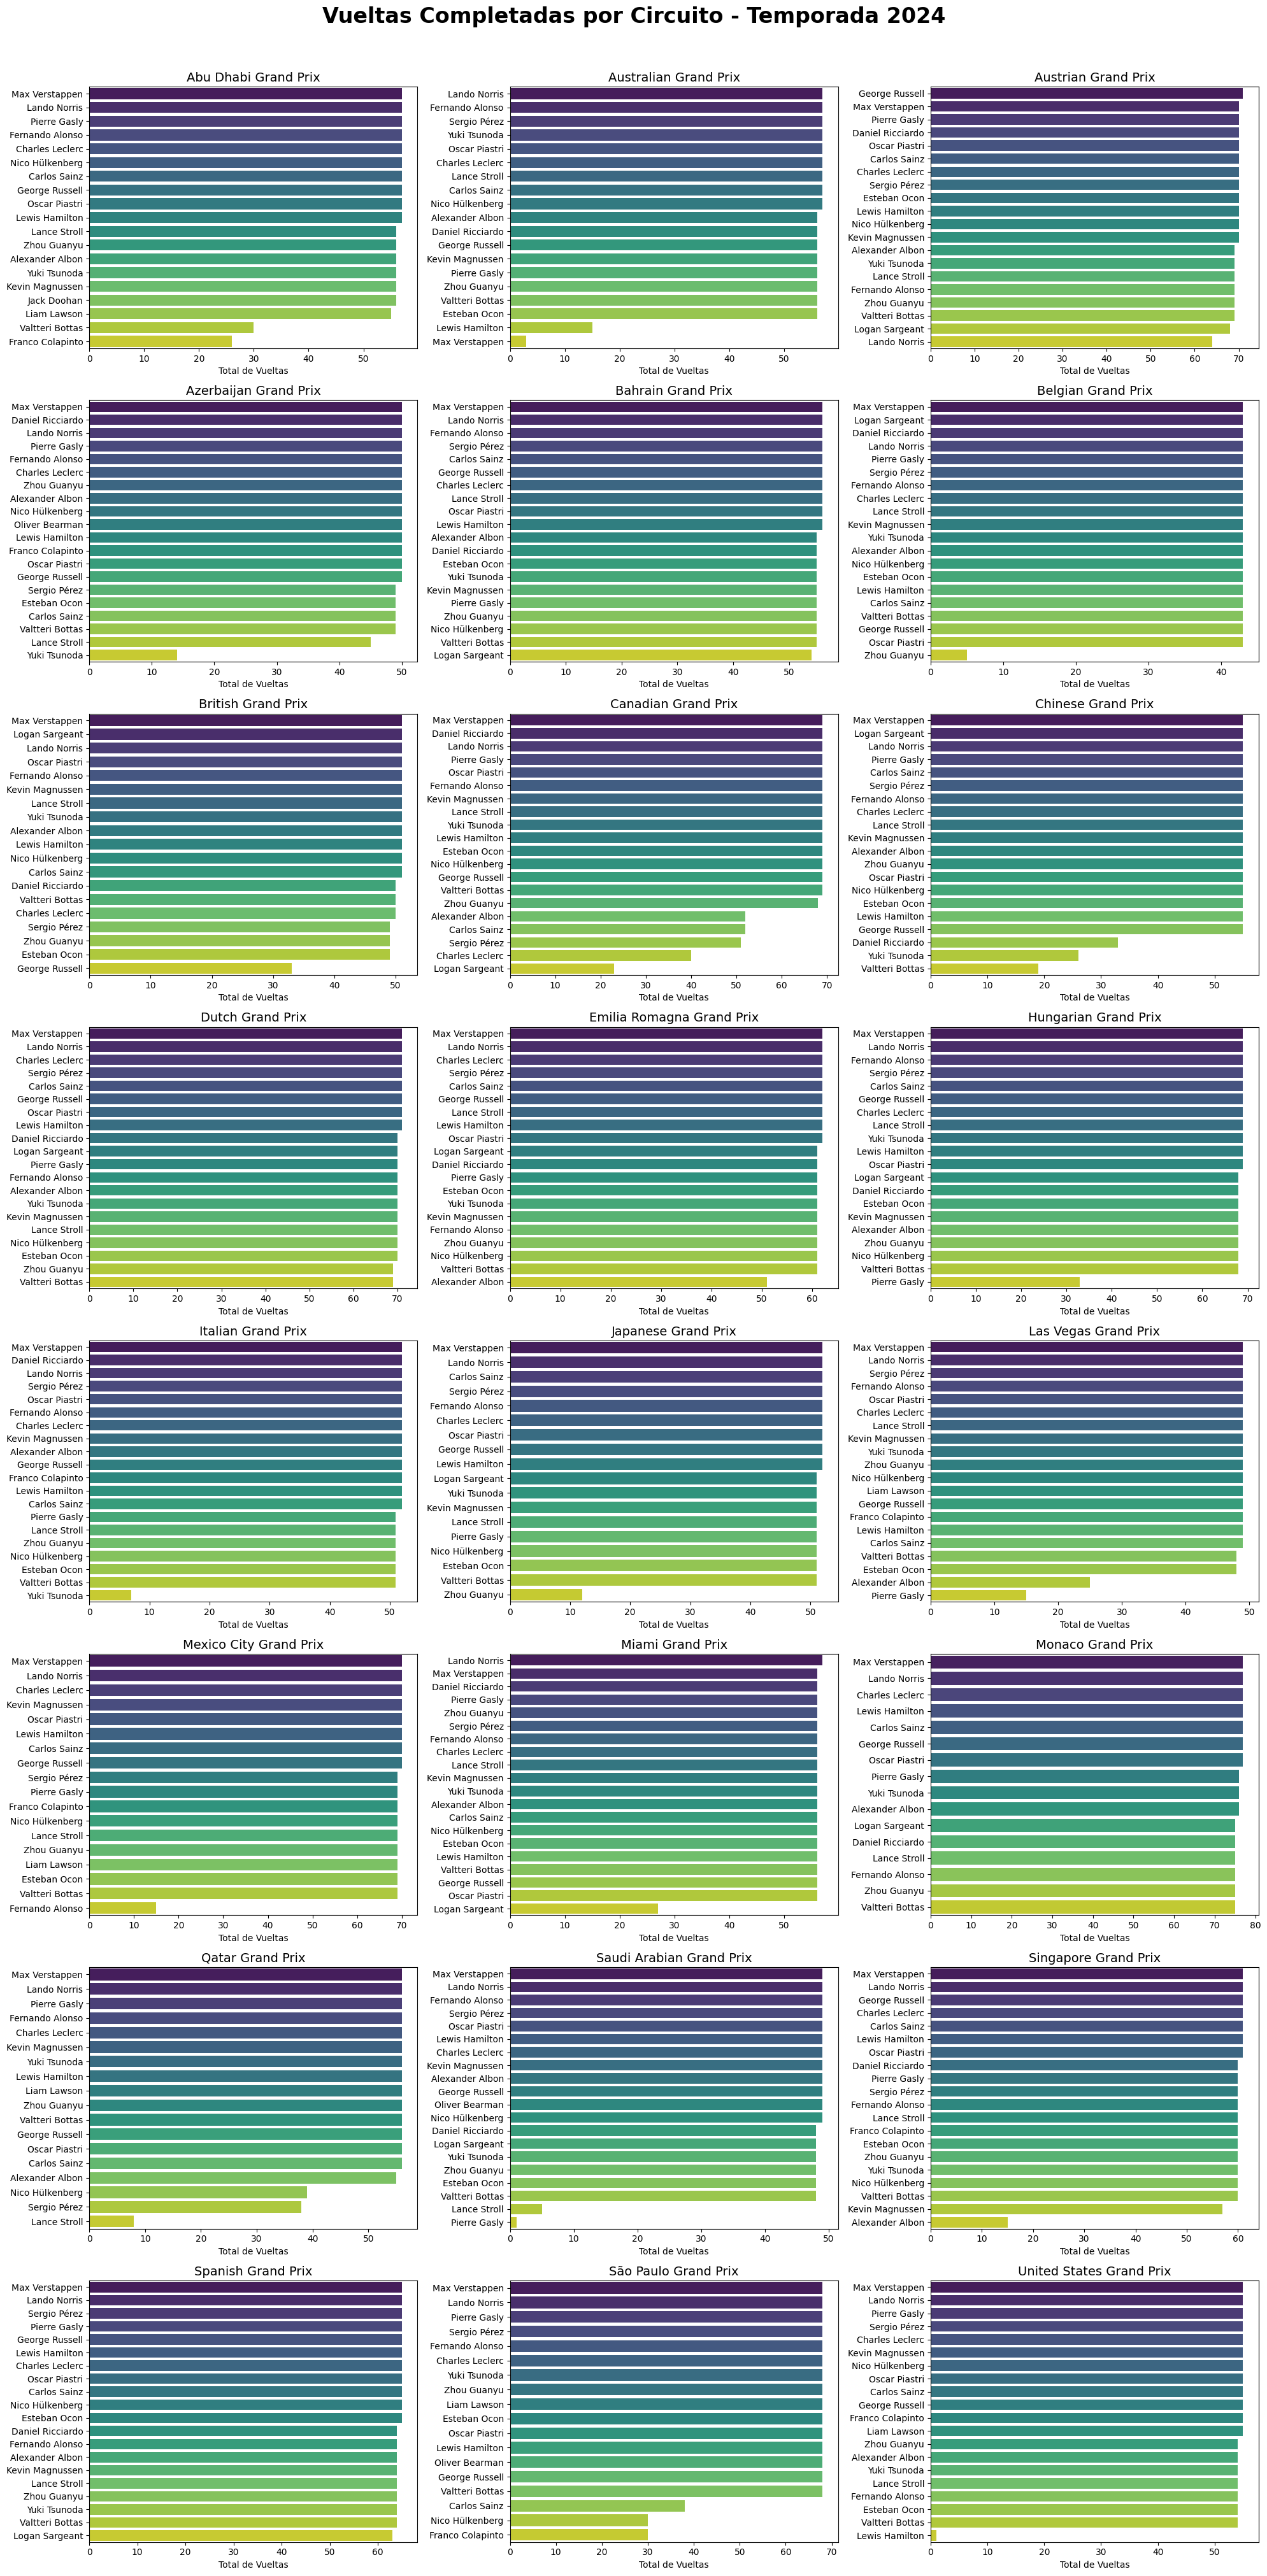

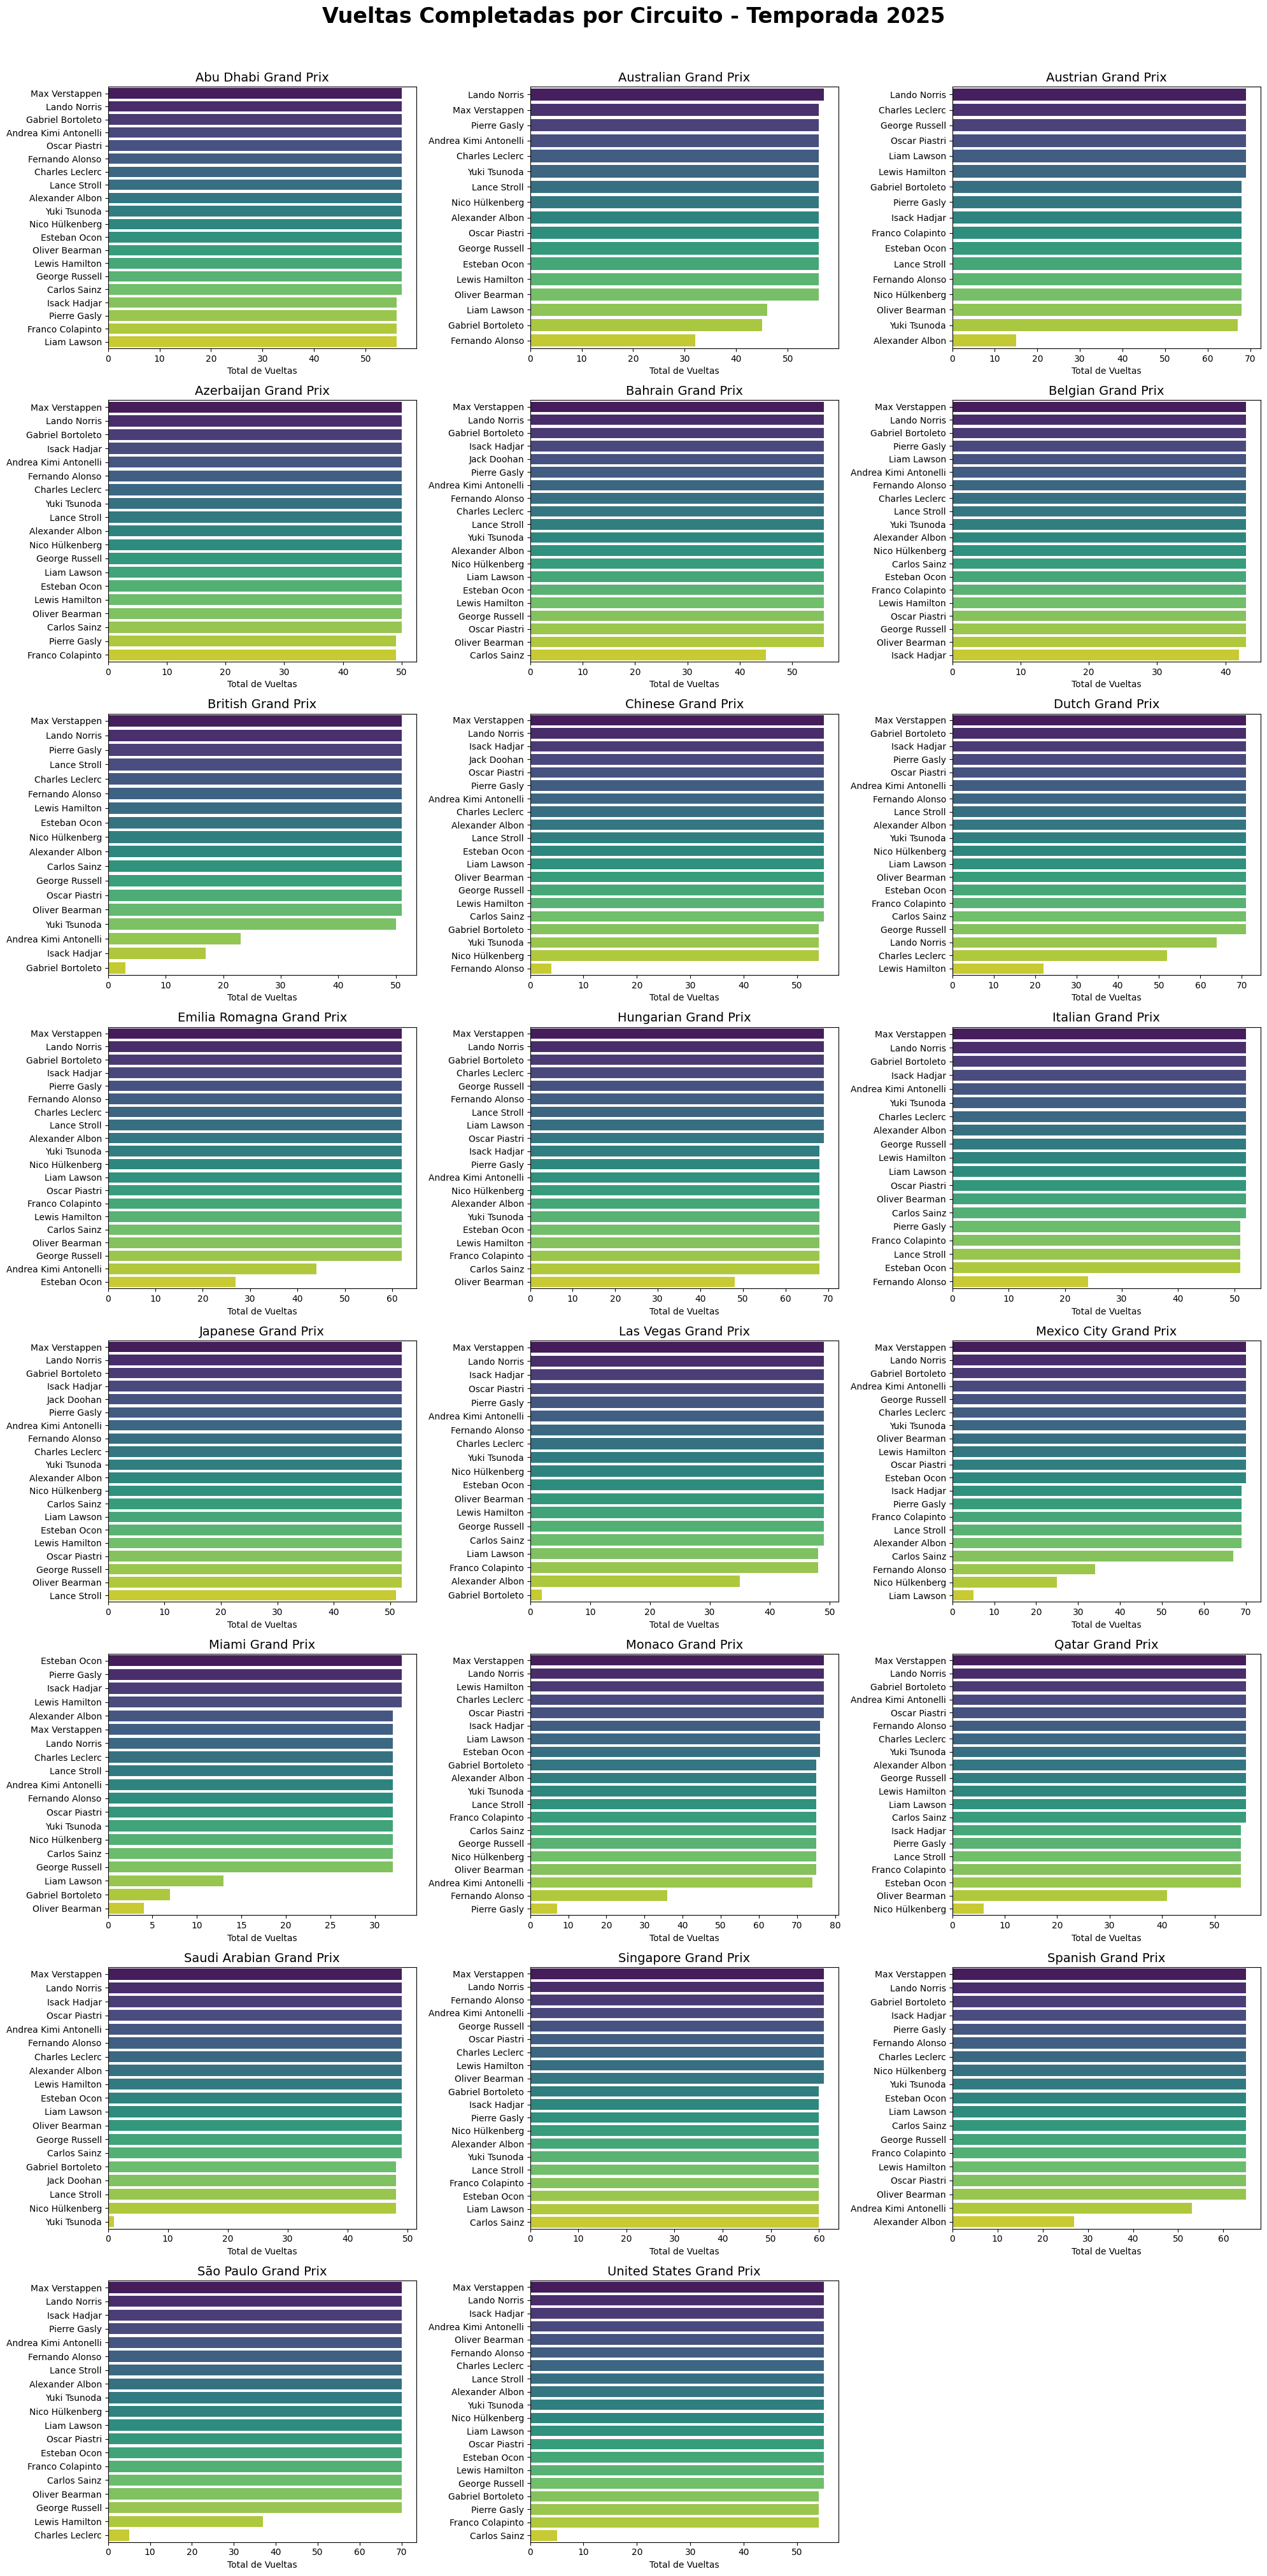

In [21]:
# Obtener los años únicos ordenados
anos = sorted(data['Year'].unique())

# Crear un diccionario para mapear la sigla del piloto a su nombre completo
map_driver_to_name = dict(zip(dim_pilotos['Driver'], dim_pilotos['full_name']))

for ano in anos:
    # Filtrar datos por año
    data_ano = data[data['Year'] == ano]

    # Obtener la lista de circuitos únicos para este año específico
    circuitos = sorted(data_ano['Race'].unique())
    num_circuitos = len(circuitos)

    # Definir la estructura de la cuadrícula (ej. 3 columnas)
    columnas = 3
    filas = int(np.ceil(num_circuitos / columnas))

    # Crear la figura principal y los subgráficos
    fig, axes = plt.subplots(filas, columnas, figsize=(20, 5 * filas))
    fig.suptitle(f'Vueltas Completadas por Circuito - Temporada {ano}', fontsize=24, weight='bold', y=1.01)
    axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

    for i, circuito in enumerate(circuitos):
        ax = axes[i]

        # Filtrar datos para el circuito actual
        data_circuito = data_ano[data_ano['Race'] == circuito]

        # Contar las vueltas (filas) por piloto usando 'Driver' y ordenar automáticamente de mayor a menor
        vueltas_piloto = data_circuito['Driver'].value_counts().reset_index()
        vueltas_piloto.columns = ['Piloto', 'Vueltas']

        # Reemplazar la sigla por el nombre completo usando el diccionario
        vueltas_piloto['Piloto'] = vueltas_piloto['Piloto'].map(map_driver_to_name).fillna(vueltas_piloto['Piloto'])

        # Crear el gráfico de barras horizontal arreglando el warning de seaborn
        sns.barplot(data=vueltas_piloto, x='Vueltas', y='Piloto', ax=ax, hue='Piloto', palette='viridis', legend=False)

        ax.set_title(f'{circuito}', fontsize=14)
        ax.set_xlabel('Total de Vueltas')
        ax.set_ylabel('')

    # Ocultar los ejes sobrantes (si la cantidad de circuitos no es múltiplo exacto de las columnas)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

* Vemos que por cada carrera, casi todos los pilotos corren todas las vueltas
* Tambien vemos los que sufrieron accidentes o abandonos, y dieron menos vueltas
* En algunos casos, como Max Verstapen en Austria y Abu Dhabi 2023, algunos piltos dan una vuelta mas que el resto. Esto se debe a que son pilotos en el podio, que se quedan una vuelta extra saludando al publico, y los sensores lo registran

### 1.7 Tratamiento de Nulls

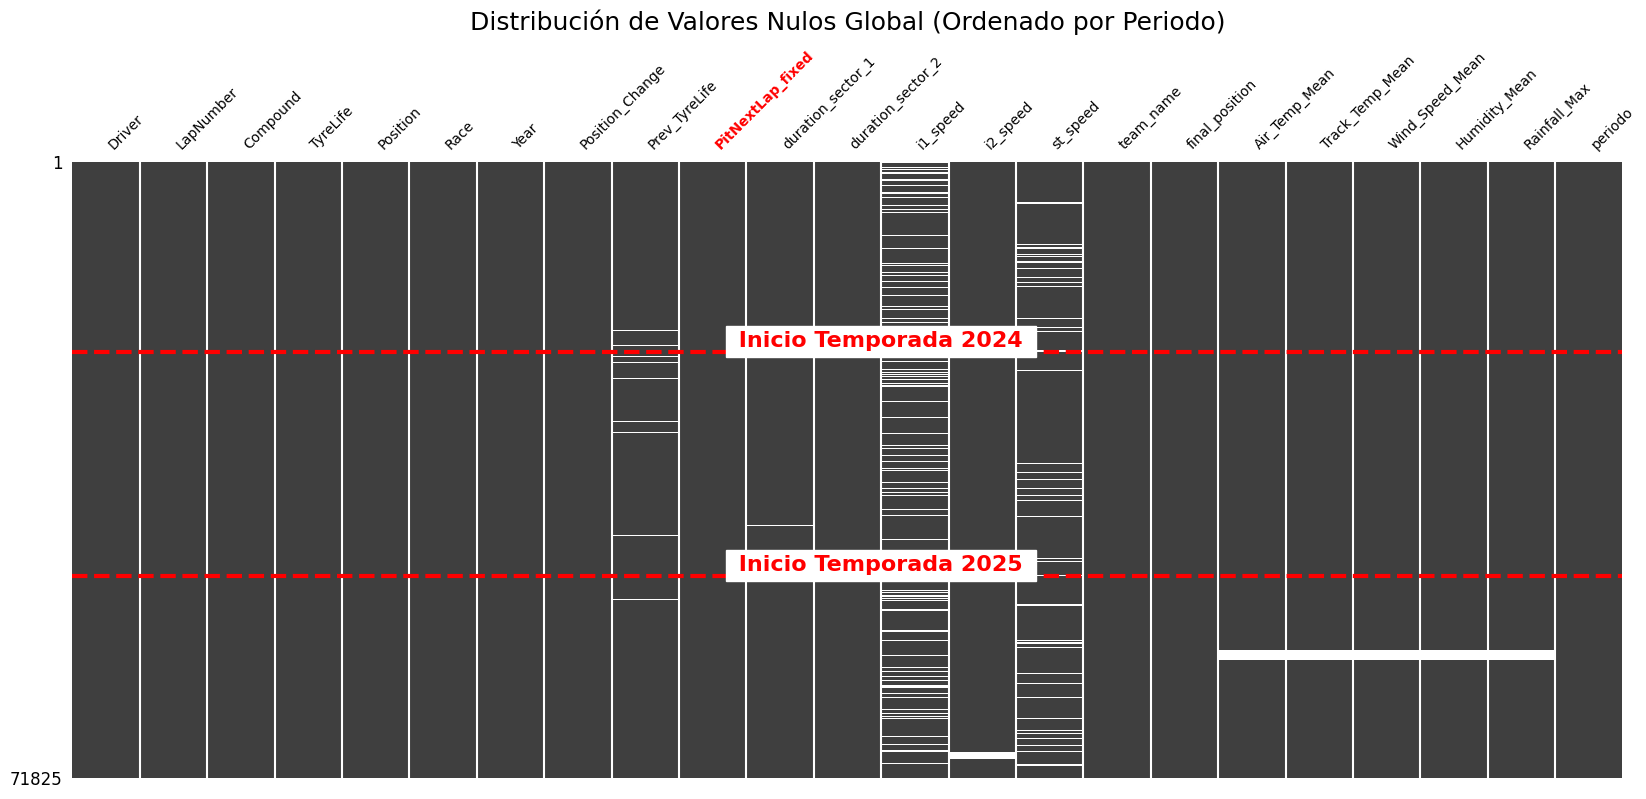

In [22]:
# 1. Ordenar cronológicamente por 'periodo' (y desempatar por carrera)
data_sorted = data.sort_values(by=['periodo', 'Race']).reset_index(drop=True)

# Eliminamos variables que no vamos a usar
to_drop = [
    "LapTime_Delta",
    "date_start",
    # "Year", # La dejamos para los ploteos
    # "periodo",
    # "duration_sector_1", # Rescatado: Ocurre antes de entrar a pits (No hay leakage)
    # "duration_sector_2", # Rescatado: Ocurre antes de entrar a pits (No hay leakage)
    "duration_sector_3",   # LEAKAGE: Aquí está la entrada a boxes
    "lap_duration"         # LEAKAGE: Contiene la suma del Sector 3
]
data_sorted.drop(columns=to_drop, inplace=True)

# Tambien eliminamos los pocos casos donde tenemos el Target con nulos
data_sorted = data_sorted.dropna(subset=['PitNextLap_fixed']).copy()

# 2. Generar la matriz de nulos
ax = msno.matrix(data_sorted, figsize=(20, 8), sparkline=False, fontsize=10)
plt.title("Distribución de Valores Nulos Global (Ordenado por Periodo)", fontsize=18, y=1.2)

# Destacar la columna target (PitNextLap_fixed)
for label in ax.get_xticklabels():
    if label.get_text() == 'PitNextLap_fixed':
        label.set_color('red')
        label.set_fontweight('bold')

# 3. Dibujar las líneas de corte para cada año
# El eje Y en esta matriz va desde 0 (arriba) hasta len(data_sorted) (abajo)
años_presentes = sorted(data_sorted['Year'].dropna().unique())

for ano in años_presentes[1:]:  # Saltamos el primer año (2023) ya que empieza en el tope
    # Encontrar la primera fila donde aparece este año
    idx_corte = data_sorted[data_sorted['Year'] == ano].index[0]

    # Dibujar la línea horizontal
    plt.axhline(y=idx_corte, color='red', linestyle='--', linewidth=3)

    # Agregar el texto indicador en el centro del gráfico (x = columnas/2)
    plt.text(
        x=data_sorted.shape[1] / 2,
        y=idx_corte - 500, # Un poco más arriba de la línea para que no se superponga
        s=f' Inicio Temporada {int(ano)} ',
        color='red',
        fontsize=16,
        weight='bold',
        ha='center',
        backgroundcolor='white'
    )

plt.show()

* Vemos como solo algunas variables tienen nulos, aunque no son muchos
* Tambien vemos los nulos en los datos del clima para Shanghai 2024, que no pudo descargar de la API

### 1.8 Split y Export de la base final

* Al tener mas de 70,000 registros, decidimos particionar en un 90% la basde de Train, y en un 10% la de Test
* Exportamos ambas bases a archivos .parquet

In [ ]:
from sklearn.model_selection import train_test_split

# Realizar el train-test split (90% train, 10% test)
train_data, test_data = train_test_split(data_sorted, test_size=0.10, random_state=42, stratify=data_sorted['PitNextLap_fixed'])

# Exportar los dataframes a archivos parquet
train_data.to_parquet('train_data.parquet', index=False)
test_data.to_parquet('test_data.parquet', index=False)

print(f"Train data exportado a 'train_data.parquet' con {len(train_data)} registros.")
print(f"Test data exportado a 'test_data.parquet' con {len(test_data)} registros.")

Train data exportado a 'train_data.parquet' con 64642 registros.
Test data exportado a 'test_data.parquet' con 7183 registros.
